## INFINITY STOCK PRICE PREDICTION

In [1]:
## to change the name across the code
## ctrl + h will open the tab the fill the new name in replace
## to change the name across the entire code so you dont have to click enter everytime
## ctrl + shift + h

import pandas as pd

infinity=pd.read_csv('../stock_data/infinity.csv') ## so it can be small letter. This is cool.
infinity=infinity.drop(columns=['high_price','low_price'])
infinity.rename(columns={'trade_date':'date'},inplace=True)
infinity['date']=pd.to_datetime(infinity['date'])
infinity['month']=infinity['date'].dt.month
infinity['quarter']=infinity['date'].dt.quarter
infinity['year']=infinity['date'].dt.year

infinity

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,42824,inf,2017-01-03,1.47,1.47,0.0,2026-04-08T02:41:25.765521+00:00,1,1,2017
1,43384,inf,2017-01-04,1.47,1.47,15000.0,2026-04-08T02:42:20.164398+00:00,1,1,2017
2,43494,inf,2017-01-05,1.47,1.47,0.0,2026-04-08T02:42:22.380516+00:00,1,1,2017
3,43604,inf,2017-01-06,1.47,1.47,0.0,2026-04-08T02:42:23.84796+00:00,1,1,2017
4,43694,inf,2017-01-09,1.47,1.47,0.0,2026-04-08T02:42:26.938159+00:00,1,1,2017
...,...,...,...,...,...,...,...,...,...,...
2258,298075,inf,2026-07-13,11.25,11.25,98802.0,2026-07-13T15:10:02.995074+00:00,7,3,2026
2259,298513,inf,2026-07-14,11.25,11.25,11815.0,2026-07-14T15:10:03.094441+00:00,7,3,2026
2260,298951,inf,2026-07-15,11.25,11.25,1220.0,2026-07-15T15:10:03.078609+00:00,7,3,2026
2261,299389,inf,2026-07-16,11.25,11.25,465.0,2026-07-16T15:10:03.113936+00:00,7,3,2026


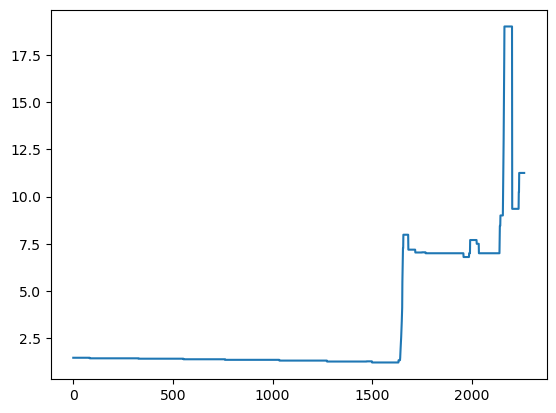

In [2]:
import matplotlib.pyplot as plt

plt.plot(infinity['close_price'])
plt.show()

In [3]:
infinity_end_month_df = (
    infinity
    .sort_values("date")
    .groupby(infinity["date"].dt.to_period("M"))
    .tail(1)
    .reset_index(drop=True)
)

infinity_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year
0,45394,inf,2017-01-31,1.47,1.47,0.0,2026-04-08T02:43:03.07753+00:00,1,1,2017
1,47216,inf,2017-02-28,1.47,1.47,0.0,2026-04-08T02:44:45.006295+00:00,2,1,2017
2,49332,inf,2017-03-31,1.47,1.47,0.0,2026-04-08T02:45:42.281198+00:00,3,1,2017
3,51159,inf,2017-04-28,1.47,1.47,0.0,2026-04-08T02:51:55.619599+00:00,4,2,2017
4,53081,inf,2017-05-31,1.44,1.44,0.0,2026-04-08T02:52:57.421655+00:00,5,2,2017
...,...,...,...,...,...,...,...,...,...,...
110,35312,inf,2026-03-31,19.00,19.00,87570.0,2026-03-31T15:00:02.085058+00:00,3,1,2026
111,281138,inf,2026-04-30,9.35,9.35,1150.0,2026-04-30T15:00:02.170664+00:00,4,2,2026
112,284204,inf,2026-05-29,9.35,9.35,10247.0,2026-05-29T15:00:02.455558+00:00,5,2,2026
113,294132,inf,2026-06-30,11.25,11.25,53952.0,2026-06-30T15:10:03.08168+00:00,6,2,2026


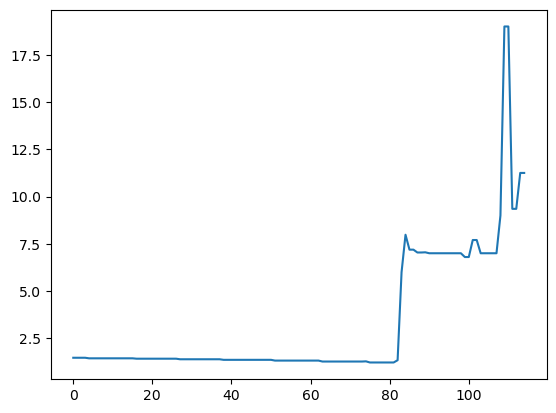

In [4]:
plt.plot(infinity_end_month_df['close_price'])
plt.show()

In [5]:
infinity_end_month_df['returns']=infinity_end_month_df['close_price'].pct_change()*100
infinity_end_month_df

,id,symbol,date,open_price,close_price,volume,created_at,month,quarter,year,returns
0,45394,inf,2017-01-31,1.47,1.47,0.0,2026-04-08T02:43:03.07753+00:00,1,1,2017,NaN
1,47216,inf,2017-02-28,1.47,1.47,0.0,2026-04-08T02:44:45.006295+00:00,2,1,2017,0.000000
2,49332,inf,2017-03-31,1.47,1.47,0.0,2026-04-08T02:45:42.281198+00:00,3,1,2017,0.000000
3,51159,inf,2017-04-28,1.47,1.47,0.0,2026-04-08T02:51:55.619599+00:00,4,2,2017,0.000000
4,53081,inf,2017-05-31,1.44,1.44,0.0,2026-04-08T02:52:57.421655+00:00,5,2,2017,-2.040816
...,...,...,...,...,...,...,...,...,...,...,...
110,35312,inf,2026-03-31,19.00,19.00,87570.0,2026-03-31T15:00:02.085058+00:00,3,1,2026,0.000000
111,281138,inf,2026-04-30,9.35,9.35,1150.0,2026-04-30T15:00:02.170664+00:00,4,2,2026,-50.789474
112,284204,inf,2026-05-29,9.35,9.35,10247.0,2026-05-29T15:00:02.455558+00:00,5,2,2026,0.000000
113,294132,inf,2026-06-30,11.25,11.25,53952.0,2026-06-30T15:10:03.08168+00:00,6,2,2026,20.320856


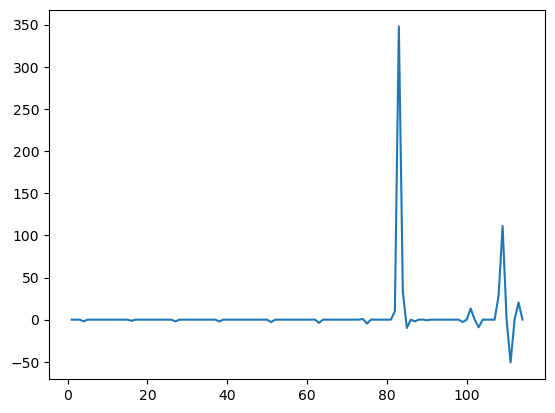

In [6]:
plt.plot(infinity_end_month_df['returns'])
plt.show()

In [7]:
## Test stationarity

from statsmodels.tsa.stattools import adfuller

result = adfuller(infinity_end_month_df['returns'].dropna())
print(result)
pvalue = result[1]
if pvalue < 0.05:
    print('stationary')
else:
    print('not stationary')

(-9.382307275768085, 6.904724601631243e-16, 0, 113, {'1%': -3.489589552580676, '5%': -2.887477210140433, '10%': -2.580604145195395}, 1008.359042589679)
stationary


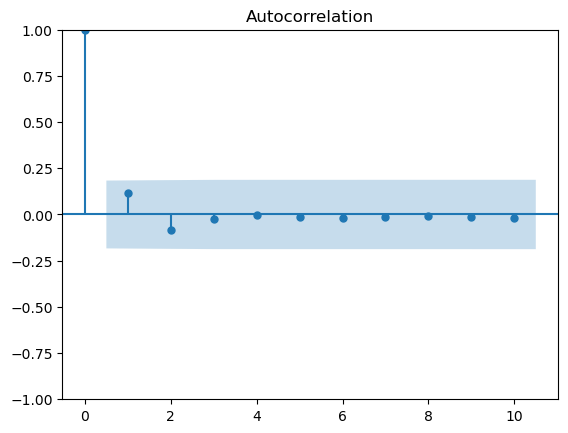

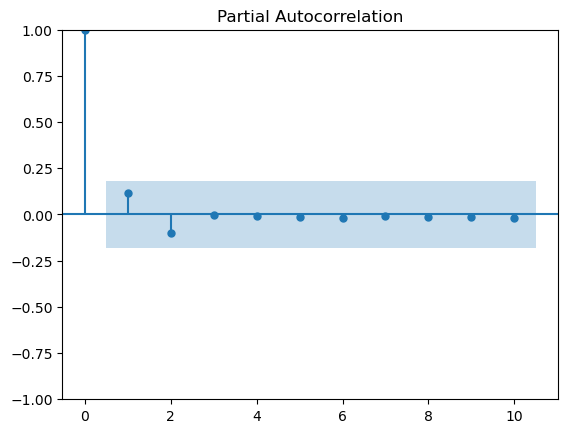

In [8]:
# Plotting the autocorrelation function and the partial autocorrelation function
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(infinity_end_month_df['returns'].dropna(), lags=10)
plot_pacf(infinity_end_month_df['returns'].dropna(), lags=10)
plt.show()

In [9]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=infinity_end_month_df['close_price'][:-10]
test=infinity_end_month_df['close_price'][-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -6.42816943926342]
[0, 0, 0, 0, 0, 1, -4.7423771700348345]
[0, 0, 0, 0, 0, 2, -2.7506822491847798]
[0, 0, 0, 0, 1, 0, -0.7800502409625567]
[0, 0, 0, 0, 1, 1, -0.7799642219272713]
[0, 0, 0, 0, 1, 2, -0.860325948109552]
[0, 0, 0, 0, 2, 0, -1.1811547874662827]
[0, 0, 0, 0, 2, 1, -0.43054417772789666]
[0, 0, 0, 0, 2, 2, -0.036347739535348644]
[0, 0, 0, 1, 0, 0, -1.190712881088884]
[0, 0, 0, 1, 0, 1, -1.3060312789096673]
[0, 0, 0, 1, 0, 2, -1.8752385464312429]
[0, 0, 0, 1, 1, 0, -0.7799180742127778]
[0, 0, 0, 1, 1, 1, -0.7817175780147048]
[0, 0, 0, 1, 1, 2, -0.854417076881655]
[0, 0, 0, 1, 2, 0, 0.17069939959625624]
[0, 0, 0, 1, 2, 1, 0.0304940749373952]
[0, 0, 0, 1, 2, 2, 0.032968812703603856]
[0, 0, 0, 2, 0, 0, -1.2562756788958316]
[0, 0, 0, 2, 0, 1, -1.4342554211758354]
[0, 0, 0, 2, 0, 2, -1.7890877203537454]
[0, 0, 0, 2, 1, 0, -0.856031572528946]
[0, 0, 0, 2, 1, 1, -0.8526959774025904]
[0, 0, 0, 2, 1, 2, -0.8592171751134228]
[0, 0, 0, 2, 2, 0, 0.10215412881547814]
[0,

In [10]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
659,2,2,0,1,1,0,-1.143349e+08
0,0,0,0,0,0,0,-6.428169e+00
27,0,0,1,0,0,0,-6.254175e+00
54,0,0,2,0,0,0,-6.072797e+00
411,1,2,0,0,2,0,-5.267530e+00
...,...,...,...,...,...,...,...
349,1,1,0,2,2,1,2.424050e-01
645,2,1,2,2,2,1,2.424249e-01
187,0,2,0,2,2,1,2.424283e-01
618,2,1,1,2,2,1,2.424712e-01


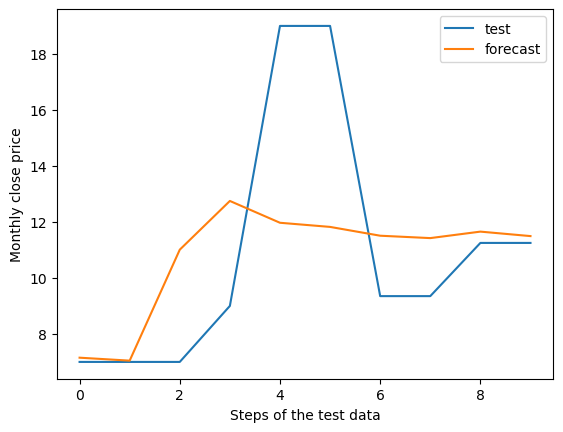

r2_score:  0.24386039683493366
rmse:  3.7452427588173616
description:  count    115.000000
mean       3.281826
std        3.497923
min        1.220000
25%        1.320000
50%        1.420000
75%        6.900000
max       19.000000
Name: close_price, dtype: float64


In [11]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

y_train=infinity_end_month_df['close_price'][:-10]
y_test=infinity_end_month_df['close_price'][-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,2,0), 
seasonal_order=(1,2,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', infinity_end_month_df.close_price.describe())

RMSE is greater than std. Lets try the returns

In [12]:
import random
random.seed(12345)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore')

train=infinity_end_month_df['returns'].dropna()[:-10]
test=infinity_end_month_df['returns'].dropna()[-10:]

# Grid Search on the SARIMA model
import numpy as np
scores = []
for p in range(3):
    for i in range(3):
        for q in range(3):
            for P in range(3):
                for D in range(3):
                    for Q in range(3):
                        try:
                            mod = SARIMAX(train, 
                            order=(p,i,q), seasonal_order=(P,D,Q,12))
                            res = mod.fit(disp=False)
                            fcst=res.forecast(steps=10)
                            score =  [p,i,q,P,D,Q,r2_score(test,fcst)]
                            print(score)
                            scores.append(score)
                            del mod
                            del res
                        except:
                            print('errored')


[0, 0, 0, 0, 0, 0, -0.07972118523931582]
[0, 0, 0, 0, 0, 1, -0.07970140029187855]
[0, 0, 0, 0, 0, 2, -0.07972808603250736]
[0, 0, 0, 0, 1, 0, -0.03662499041122702]
[0, 0, 0, 0, 1, 1, -0.19296741517953708]
[0, 0, 0, 0, 1, 2, -1.5172635980376343]
[0, 0, 0, 0, 2, 0, -8.178753475901896]
[0, 0, 0, 0, 2, 1, -0.032967508300500326]
[0, 0, 0, 0, 2, 2, -1.5259734367291045]
[0, 0, 0, 1, 0, 0, -0.07970067753871168]
[0, 0, 0, 1, 0, 1, -0.0797003656717934]
[0, 0, 0, 1, 0, 2, -0.07972859953336031]
[0, 0, 0, 1, 1, 0, -4.742297891092655]
[0, 0, 0, 1, 1, 1, -2.0191790433676533]
[0, 0, 0, 1, 1, 2, -0.1978568295785743]
[0, 0, 0, 1, 2, 0, -4.334671588976419]
[0, 0, 0, 1, 2, 1, -6.775568729906491]
[0, 0, 0, 1, 2, 2, -2.957558586567507]
[0, 0, 0, 2, 0, 0, -0.07972739276591367]
[0, 0, 0, 2, 0, 1, -0.07972825164544206]
[0, 0, 0, 2, 0, 2, -0.07969457561667159]
[0, 0, 0, 2, 1, 0, -2.8051703035473787]
[0, 0, 0, 2, 1, 1, -2.0556732905748802]
[0, 0, 0, 2, 1, 2, -0.18324655882300322]
[0, 0, 0, 2, 2, 0, -14.331266436

In [13]:
res = pd.DataFrame(scores)
res.columns = ['p', 'i', 'q', 'P', 'D', 'Q', 'score']
result = res.sort_values('score')
result

,p,i,q,P,D,Q,score
227,0,2,2,1,1,2,-9572.406478
335,1,1,0,1,1,2,-224.663709
92,0,1,0,1,1,0,-139.707531
184,0,2,0,2,2,0,-18.156296
425,1,2,0,2,2,0,-14.813172
...,...,...,...,...,...,...,...
703,2,2,2,1,0,1,-0.002132
463,1,2,2,1,0,0,-0.001089
455,1,2,2,0,0,1,-0.001082
454,1,2,2,0,0,0,-0.000819


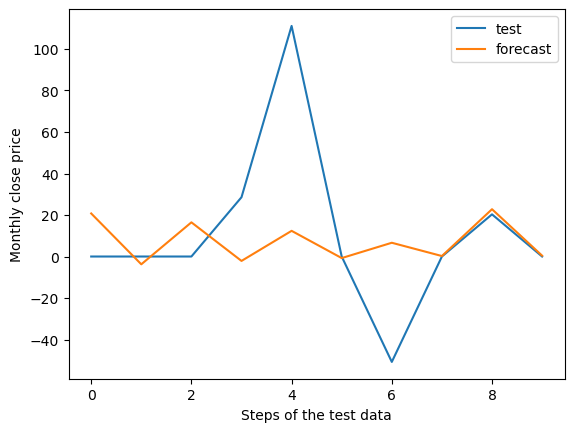

r2_score:  0.016748513204367765
rmse:  38.35512781507832
description:  count    114.000000
mean       4.124697
std       34.789923
min      -50.789474
25%        0.000000
50%        0.000000
75%        0.000000
max      347.761194
Name: returns, dtype: float64


In [14]:
# Fitting a SARIMAX model with our best model 
# order=(2,0,1), seasonal_order=(1,2,1,10)

import random
random.seed(12345)
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

y_train=infinity_end_month_df['returns'].dropna()[:-10]
y_test=infinity_end_month_df['returns'].dropna()[-10:]

# scaler=StandardScaler()
# exog_train_scaled=scaler.fit_transform(X_full[:-10])
# exog_test_scaled=scaler.transform(X_full[-10:])

mod = SARIMAX(
y_train,
order=(2,0,2), 
seasonal_order=(0,2,1,12),
)

res = mod.fit(disp=False)
fcst = res.forecast(steps=10)

plt.plot(list(y_test))
plt.plot(list(fcst))
plt.xlabel('Steps of the test data')
plt.ylabel('Monthly close price')
plt.legend(['test', 'forecast'])
plt.show()
print('r2_score: ',r2_score(y_test, fcst))
print('rmse: ', np.sqrt(mean_squared_error(y_test,fcst)))
print('description: ', infinity_end_month_df.returns.dropna().describe())

Very horrible. We will work with close_price
